# Part 2 — Ensemble: Swin Tiny + LeViT-128 + DenseNet121
Run this in a **fresh** Colab runtime, AFTER Part 1 (`Part1_Swin_Predictions_Generator.ipynb`)
has been run at least once and saved its `.npy` files to Drive.

This notebook loads LeViT-128 and DenseNet121 normally (with `TF_USE_LEGACY_KERAS=1`, since
LeViT needs it), and loads Swin's predictions from the cached `.npy` files instead of
running Swin here — Swin and LeViT cannot share a Python session (see Part 1's note).

Run cells top to bottom (or Runtime → Run all).

## Cell 1 — Setup (installs + imports)

In [1]:
!pip install -U keras-cv-attention-models tf_keras -q

import os
# IMPORTANT: must be set BEFORE importing tensorflow/keras.
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import shutil
import zipfile
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from keras_cv_attention_models import levit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import logging
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("TF_USE_LEGACY_KERAS:", os.environ.get("TF_USE_LEGACY_KERAS"))
print("All imports successful!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.1/191.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 806.1/806.1 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 18.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0

## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set (images + CSV)

In [3]:
split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Test folder ready: True


## Cell 4 — Load Swin's cached predictions (from Part 1)

In [4]:
swin_cache_folder = '/content/drive/MyDrive/thesis_ensemble_outputs/swin_predictions_cache'
assert os.path.exists(swin_cache_folder), (
    "Swin predictions cache not found. Run Part1_Swin_Predictions_Generator.ipynb "
    "in a fresh runtime first."
)

pred_swin = np.load(f'{swin_cache_folder}/pred_swin.npy')
val_pred_swin = np.load(f'{swin_cache_folder}/val_pred_swin.npy')
true_labels = np.load(f'{swin_cache_folder}/true_labels.npy')
val_true_labels = np.load(f'{swin_cache_folder}/val_true_labels.npy')
with open(f'{swin_cache_folder}/class_names.json') as f:
    class_names = json.load(f)

num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}

acc_swin = accuracy_score(true_labels, np.argmax(pred_swin, axis=1))
print(f"Loaded cached Swin Tiny TEST accuracy: {acc_swin:.4f}")
print("Classes:", class_names)

Loaded cached Swin Tiny TEST accuracy: 0.9842
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 5 — Load test + val CSVs (for filepaths, in the same row order as Part 1)

In [5]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

val_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
val_df['filepath'] = val_df['filepath'].str.replace('/content/split_dataset', '/content')

# Sanity check: row order must match Part 1's, since pred_swin was computed in that order
assert len(test_df) == len(true_labels), "Test set size mismatch vs cached Swin predictions!"
assert len(val_df) == len(val_true_labels), "Val set size mismatch vs cached Swin predictions!"
print("Test samples:", len(test_df), "| Val samples:", len(val_df))

Test samples: 2538 | Val samples: 2519


## Cell 6 — Config

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values
val_filepaths = val_df['filepath'].values

## Cell 7 — Build the loading function
LeViT-128 and DenseNet121 both take raw `float32` pixels in [0, 255] (their normalization/`preprocess_input` is baked into each model), so they share one dataset.

In [7]:
def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img  # stays float32, values 0-255

## Cell 8 — Build the test/val dataset(s)

In [8]:
def make_ds(paths, load_fn):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_float32 = make_ds(filepaths, load_float32)      # for LeViT-128 and DenseNet121
val_ds_float32 = make_ds(val_filepaths, load_float32)

print("Dataset ready")

Dataset ready


## Cell 9 — Load LeViT-128 and DenseNet121

In [9]:
# --- LeViT-128: rebuild architecture exactly as in training, then load trained weights ---
levit_backbone = levit.LeViT128(input_shape=(224, 224, 3), num_classes=0, pretrained="imagenet")
levit_backbone.trainable = False

levit_inputs = layers.Input(shape=(224, 224, 3), dtype='float32')

class TorchNormalize(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.mean = tf.constant([0.485, 0.456, 0.406]) * 255.0
        self.std = tf.constant([0.229, 0.224, 0.225]) * 255.0

    def call(self, x):
        return (x - self.mean) / self.std

x = TorchNormalize()(levit_inputs)

x = levit_backbone(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
levit_outputs = layers.Dense(num_classes, activation='softmax')(x)

levit_model = models.Model(levit_inputs, levit_outputs)
levit_model.load_weights('/content/drive/MyDrive/thesis_levit_outputs/best_levit_model.keras')
print("LeViT-128 model rebuilt and weights loaded!")

37854624/37854624 [==============================] - 1s 0us/step
>>>> Load pretrained from: /root/.keras/models/levit128_imagenet.h5
LeViT-128 model rebuilt and weights loaded!


In [10]:
# --- DenseNet121: rebuild architecture, then load weights extracted from the .keras file ---
# (plain load_model fails under TF_USE_LEGACY_KERAS=1 -- this .keras file is native Keras 3 format)
densenet_model_path = '/content/drive/MyDrive/thesis_densenet121_outputs/best_densenet121_model.keras'
print("Model file exists:", os.path.exists(densenet_model_path))

densenet_weights_extract_dir = '/content/densenet121_weights_extracted'
if not os.path.exists(densenet_weights_extract_dir):
    with zipfile.ZipFile(densenet_model_path, 'r') as zip_ref:
        zip_ref.extractall(densenet_weights_extract_dir)

densenet_weights_path = None
for root, dirs, files in os.walk(densenet_weights_extract_dir):
    for fname in files:
        if fname.endswith('.weights.h5') or fname == 'model.weights.h5':
            densenet_weights_path = os.path.join(root, fname)
            break
print("Weights file found:", densenet_weights_path)

densenet_base = tf.keras.applications.DenseNet121(
    include_top=False,
    weights=None,
    input_shape=(224, 224, 3)
)

densenet_input = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.densenet.preprocess_input(densenet_input)
x = densenet_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
densenet_output = layers.Dense(num_classes, activation='softmax')(x)

densenet_model = models.Model(densenet_input, densenet_output)
densenet_model.load_weights(densenet_weights_path)
print("DenseNet121 rebuilt and weights loaded successfully")

Model file exists: True
Weights file found: /content/densenet121_weights_extracted/model.weights.h5
DenseNet121 rebuilt and weights loaded successfully


## Cell 10 — Predict on test + val sets, sanity-check accuracy

In [11]:
pred_levit = levit_model.predict(test_ds_float32, verbose=1)
acc_levit = accuracy_score(true_labels, np.argmax(pred_levit, axis=1))
print(f"LeViT-128 TEST accuracy: {acc_levit:.4f}")

pred_densenet = densenet_model.predict(test_ds_float32, verbose=1)
acc_densenet = accuracy_score(true_labels, np.argmax(pred_densenet, axis=1))
print(f"DenseNet121 TEST accuracy: {acc_densenet:.4f}")

val_pred_levit = levit_model.predict(val_ds_float32, verbose=1)
val_pred_densenet = densenet_model.predict(val_ds_float32, verbose=1)
print("Val predictions ready")

80/80 [==============================] - 15s 124ms/step
LeViT-128 TEST accuracy: 0.9515
80/80 [==============================] - 15s 140ms/step
DenseNet121 TEST accuracy: 0.9689
79/79 [==============================] - 10s 126ms/step
Val predictions ready


## Cell 11 — Ensemble (simple average) + accuracy comparison

In [12]:
ensemble_probs = (pred_swin + pred_levit + pred_densenet) / 3.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

acc_ensemble = accuracy_score(true_labels, ensemble_preds)

print("=" * 55)
print("RESULTS (Simple Average Ensemble)")
print("=" * 55)
print(f"Swin Tiny accuracy:          {acc_swin:.4f}")
print(f"LeViT-128 accuracy:          {acc_levit:.4f}")
print(f"DenseNet121 accuracy:          {acc_densenet:.4f}")
print(f"Ensemble (avg) accuracy:     {acc_ensemble:.4f}")

RESULTS (Simple Average Ensemble)
Swin Tiny accuracy:          0.9842
LeViT-128 accuracy:          0.9515
DenseNet121 accuracy:          0.9689
Ensemble (avg) accuracy:     0.9783


## Cell 12 — Weighted ensemble (weights tuned on VAL set, evaluated once on TEST set)

In [13]:
best_w = (1/3, 1/3, 1/3)
best_val_acc = accuracy_score(
    val_true_labels,
    np.argmax((val_pred_swin + val_pred_levit + val_pred_densenet) / 3.0, axis=1)
)

step = 0.05
for w_swin in np.arange(0.0, 1.0 + step, step):
    for w_levit in np.arange(0.0, 1.0 - w_swin + step, step):
        w_densenet = 1.0 - w_swin - w_levit
        if w_densenet < -1e-9:
            continue
        w_densenet = max(w_densenet, 0.0)
        val_probs = (w_swin * val_pred_swin) + (w_levit * val_pred_levit) + (w_densenet * val_pred_densenet)
        val_acc = accuracy_score(val_true_labels, np.argmax(val_probs, axis=1))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_w = (round(w_swin, 2), round(w_levit, 2), round(w_densenet, 2))

print(f"Best weighted combo (found on VAL set) [w_swin, w_levit, w_densenet]: {best_w}")
print(f"Val accuracy with this combo: {best_val_acc:.4f}")

w_swin_final, w_levit_final, w_densenet_final = best_w
test_probs_weighted = (w_swin_final * pred_swin) + (w_levit_final * pred_levit) + (w_densenet_final * pred_densenet)
ensemble_preds_weighted = np.argmax(test_probs_weighted, axis=1)
acc_ensemble_weighted = accuracy_score(true_labels, ensemble_preds_weighted)

print(f"\nFinal TEST accuracy with tuned weights: {acc_ensemble_weighted:.4f}")

Best weighted combo (found on VAL set) [w_swin, w_levit, w_densenet]: (np.float64(0.65), np.float64(0.0), np.float64(0.35))
Val accuracy with this combo: 0.9857

Final TEST accuracy with tuned weights: 0.9866


## Cell 13 — Classification report

In [14]:
report = classification_report(true_labels, ensemble_preds, target_names=class_names)
print(report)

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.97      0.98      0.98       197
       Corn_Gray_Leaf_Spot       0.95      0.94      0.95       177
              Corn_Healthy       0.99      0.99      0.99       175
          Corn_Leaf_Blight       0.94      0.94      0.94       173
Rice_Bacterial_Leaf_Blight       0.98      0.98      0.98       294
           Rice_Brown_Spot       1.00      0.97      0.99       271
              Rice_Healthy       0.99      1.00      0.99       331
           Rice_Leaf_Blast       0.96      0.98      0.97       257
          Wheat_Brown_Rust       0.97      0.99      0.98       184
             Wheat_Healthy       0.99      0.98      0.99       207
          Wheat_Loose_Smut       0.99      0.99      0.99        80
         Wheat_Yellow_Rust       0.99      0.99      0.99       192

                  accuracy                           0.98      2538
                 macro avg       0.98      0.9

## Cell 14 — Confusion matrix + save everything to Drive

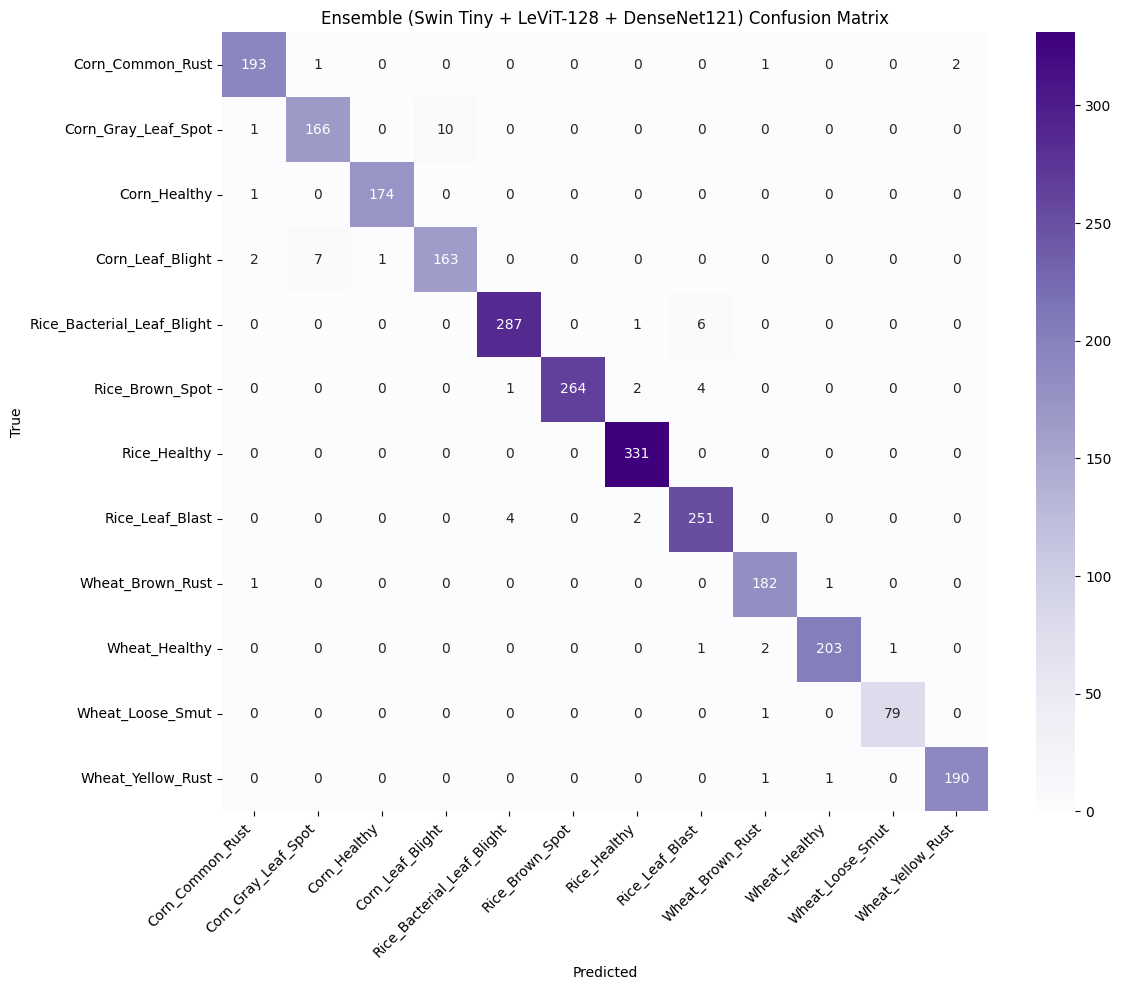

Results saved to: /content/drive/MyDrive/thesis_ensemble_outputs


In [15]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)

with open(f'{output_folder}/ensemble_swin_levit_densenet_report.txt', 'w') as f:
    f.write(f"Swin Tiny accuracy: {acc_swin:.4f}\n")
    f.write(f"LeViT-128 accuracy: {acc_levit:.4f}\n")
    f.write(f"DenseNet121 accuracy: {acc_densenet:.4f}\n")
    f.write(f"Ensemble (simple average) accuracy: {acc_ensemble:.4f}\n")
    f.write(f"Best weighted combo [w_swin, w_levit, w_densenet] (tuned on val set): {best_w}\n")
    f.write(f"Ensemble (weighted) test accuracy: {acc_ensemble_weighted:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(true_labels, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Ensemble (Swin Tiny + LeViT-128 + DenseNet121) Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_folder}/ensemble_swin_levit_densenet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {output_folder}")